# 🎯 Robust regression engine

## 🧹 Part B: Dataset Understanding & Preparation

* You are provided with a real estate dataset containing:
* Property size and structural attributes 
* Location-based numerical indicators 
* Property age and renovation details 
* Target variable: House Price 
* Dataset: Access from here

In [ ]:
import pandas as pd

df = pd.read_csv("Advanced_Regression_HousePrice_Dataset_3800 - Advanced_Regression_HousePrice_Dataset_3800.csv (1).csv")

df.head()

,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,200001,2014-01-01,2181,6,4,8.1,21,3.8,0,0,4.84,35154898
1,200002,2019-12-01,2383,5,4,5.3,28,10.9,1,1,2.89,26710893
2,200003,2016-10-01,1047,3,3,5.9,7,27.5,0,1,4.04,11216242
3,200004,2013-03-01,1753,4,3,7.0,27,12.1,0,0,3.28,21984310
4,200005,2013-07-01,1728,4,4,10.0,32,1.4,0,1,3.84,25080429


In [12]:
df.shape

(3800, 12)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   property_id       3800 non-null   int64  
 1   sale_date         3800 non-null   object 
 2   area_sqft         3800 non-null   int64  
 3   bedrooms          3800 non-null   int64  
 4   bathrooms         3800 non-null   int64  
 5   location_score    3800 non-null   float64
 6   property_age      3800 non-null   int64  
 7   distance_city_km  3800 non-null   float64
 8   near_school       3800 non-null   int64  
 9   near_metro        3800 non-null   int64  
 10  crime_rate_index  3800 non-null   float64
 11  house_price_inr   3800 non-null   int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 356.4+ KB


In [14]:
df.describe()

,property_id,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
count,3800.00000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3.800000e+03
mean,201900.50000,1716.925526,3.428158,2.916316,6.502237,22.537105,13.085132,0.548421,0.472895,4.242911,2.071940e+07
std,1097.10984,582.996559,1.356682,1.133540,1.766945,12.325740,6.537425,0.497715,0.499330,2.045371,8.707465e+06
min,200001.00000,500.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.500000,1.506126e+06
25%,200950.75000,1322.000000,2.000000,2.000000,5.300000,14.000000,8.500000,0.000000,0.000000,2.810000,1.446895e+07
50%,201900.50000,1700.500000,3.000000,3.000000,6.500000,20.000000,13.000000,1.000000,0.000000,4.220000,1.989180e+07
75%,202850.25000,2105.000000,4.000000,4.000000,7.700000,29.000000,17.500000,1.000000,1.000000,5.650000,2.596062e+07
max,203800.00000,3776.000000,7.000000,6.000000,10.000000,80.000000,38.700000,1.000000,1.000000,12.000000,5.930315e+07


### Tasks:

### 6. Identify features and target variable.

In [15]:
# Features
X = df.drop("house_price_inr", axis=1)

# Target variable
y = df["house_price_inr"]

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['property_id', 'sale_date', 'area_sqft', 'bedrooms', 'bathrooms',
       'location_score', 'property_age', 'distance_city_km', 'near_school',
       'near_metro', 'crime_rate_index'],
      dtype='object')

Target:
house_price_inr


### 💡 Insight 

- The **target** is `house_price_inr` (mean ≈ ₹2.07 crore, range ≈ ₹15 lakh to ₹5.9 crore). The dataset has **3,800 rows and no missing values**.
- `X` initially contains 11 columns, including `property_id` (a pure identifier, correlation with price ≈ −0.01) and `sale_date` (text type). Neither is directly useful for modeling, so both are dropped in Q8.
- The strongest price drivers are `area_sqft` (r ≈ 0.85), `bedrooms` (0.73), `bathrooms` (0.61), `location_score` (0.43) and `distance_city_km` (−0.28). `near_school`, `near_metro` and `crime_rate_index` show very weak direct correlation with price.

### 7. Perform a train-test split.

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (3040, 11)
X_test: (760, 11)
y_train: (3040,)
y_test: (760,)


### 💡 Insight 

- The 80:20 split gives **3,040 training** and **760 test** samples; `random_state=42` makes the result reproducible.
- A random split assumes rows are independent. This assumption is cross-checked with a time-based split in Q13.

### 8. Apply basic preprocessing (scaling where required).

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = df[
    [
        "area_sqft",
        "bedrooms",
        "bathrooms",
        "location_score",
        "property_age",
        "distance_city_km",
        "near_school",
        "near_metro",
        "crime_rate_index"
    ]
]

y = df["house_price_inr"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


### 💡 Insight 

- `StandardScaler` is **fit on the training data only** and then applied to the test data, so there is **no data leakage**.
- After dropping `property_id` and `sale_date`, **9 numeric features** are used.
- Scaling is necessary for Ridge, Lasso and SVR (penalty- and distance-based models). Tree-based models do not need it, so they are trained on unscaled data.

## 📈 Part C: Regularized Linear Models

### 9. Implement Ridge Regression (L2).

In [26]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

ridge_train_pred = ridge.predict(X_train_scaled)
ridge_test_pred = ridge.predict(X_test_scaled)

ridge_train_error = mean_squared_error(y_train, ridge_train_pred)
ridge_test_error = mean_squared_error(y_test, ridge_test_pred)

print("Ridge Training Error:", ridge_train_error)
print("Ridge Validation Error:", ridge_test_error)

Ridge Training Error: 6253047097253.315
Ridge Validation Error: 6545419443619.511


### 💡 Insight 

- Ridge (α=1) gives a **Training MSE ≈ 6.25×10¹²** and **Validation MSE ≈ 6.55×10¹²**. The gap is only ~5%, so the model is stable.
- RMSE ≈ ₹25.6 lakh, which is roughly 12% of the average price (₹2.07 crore).

### 10. Implement Lasso Regression (L1).

In [27]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=1.0)

lasso.fit(X_train_scaled, y_train)

lasso_train_pred = lasso.predict(X_train_scaled)
lasso_test_pred = lasso.predict(X_test_scaled)

lasso_train_error = mean_squared_error(y_train, lasso_train_pred)
lasso_test_error = mean_squared_error(y_test, lasso_test_pred)

print("Lasso Training Error:", lasso_train_error)
print("Lasso Validation Error:", lasso_test_error)

Lasso Training Error: 6253028346903.975
Lasso Validation Error: 6543996619352.281


### 💡 Insight 

- Lasso (α=1) errors are almost identical to Ridge (Training ≈ 6.25×10¹², Validation ≈ 6.54×10¹²).
- No coefficient was shrunk to zero. The coefficients are on the order of 10⁴–10⁷, so α=1 is negligible in comparison and no feature selection effect is visible.

### 11. Tune the regularization parameter (α) using cross-validation.

In [28]:
from sklearn.model_selection import GridSearchCV

alphas = [0.01, 0.1, 1, 10, 100]

# Ridge
ridge_grid = GridSearchCV(
    Ridge(),
    {"alpha": alphas},
    cv=5,
    scoring="neg_mean_squared_error"
)

ridge_grid.fit(X_train_scaled, y_train)

print("Best Ridge Alpha:", ridge_grid.best_params_["alpha"])


# Lasso
lasso_grid = GridSearchCV(
    Lasso(),
    {"alpha": alphas},
    cv=5,
    scoring="neg_mean_squared_error"
)

lasso_grid.fit(X_train_scaled, y_train)

print("Best Lasso Alpha:", lasso_grid.best_params_["alpha"])

Best Ridge Alpha: 1
Best Lasso Alpha: 100


### 💡 Insight 

- The best **Ridge α is 1** (middle of the grid) and the best **Lasso α is 100**.
- Lasso's best α sits at the **upper edge** of the grid, so trying larger values (e.g. 500, 1000+) could be worthwhile.
- Tuning barely changed performance. With only 9 features and a strong signal, the data needs little regularization.

### 12. Compare Ridge and Lasso based on:



* Training error
* Validation error

In [29]:
# Best models
best_ridge = ridge_grid.best_estimator_
best_lasso = lasso_grid.best_estimator_

# Predictions
ridge_train_pred = best_ridge.predict(X_train_scaled)
ridge_test_pred = best_ridge.predict(X_test_scaled)

lasso_train_pred = best_lasso.predict(X_train_scaled)
lasso_test_pred = best_lasso.predict(X_test_scaled)

# Errors
ridge_train_error = mean_squared_error(y_train, ridge_train_pred)
ridge_test_error = mean_squared_error(y_test, ridge_test_pred)

lasso_train_error = mean_squared_error(y_train, lasso_train_pred)
lasso_test_error = mean_squared_error(y_test, lasso_test_pred)

print("Ridge Training Error:", ridge_train_error)
print("Ridge Validation Error:", ridge_test_error)

print("\nLasso Training Error:", lasso_train_error)
print("Lasso Validation Error:", lasso_test_error)

Ridge Training Error: 6253047097253.315
Ridge Validation Error: 6545419443619.511

Lasso Training Error: 6253028410486.958
Lasso Validation Error: 6544107497269.08


* Feature coefficient behavior

In [30]:
comparison = pd.DataFrame({
    "Feature": X.columns,
    "Ridge Coefficient": best_ridge.coef_,
    "Lasso Coefficient": best_lasso.coef_
})

print(comparison)

            Feature  Ridge Coefficient  Lasso Coefficient
0         area_sqft       6.937545e+06       6.944831e+06
1          bedrooms       2.973655e+05       2.911937e+05
2         bathrooms       2.853268e+05       2.853815e+05
3    location_score       3.676865e+06       3.678911e+06
4      property_age      -6.513024e+05      -6.513909e+05
5  distance_city_km      -3.016962e+04      -2.873756e+04
6       near_school       1.697147e+04       1.680345e+04
7        near_metro       5.820432e+04       5.819679e+04
8  crime_rate_index      -1.354728e+05      -1.353088e+05


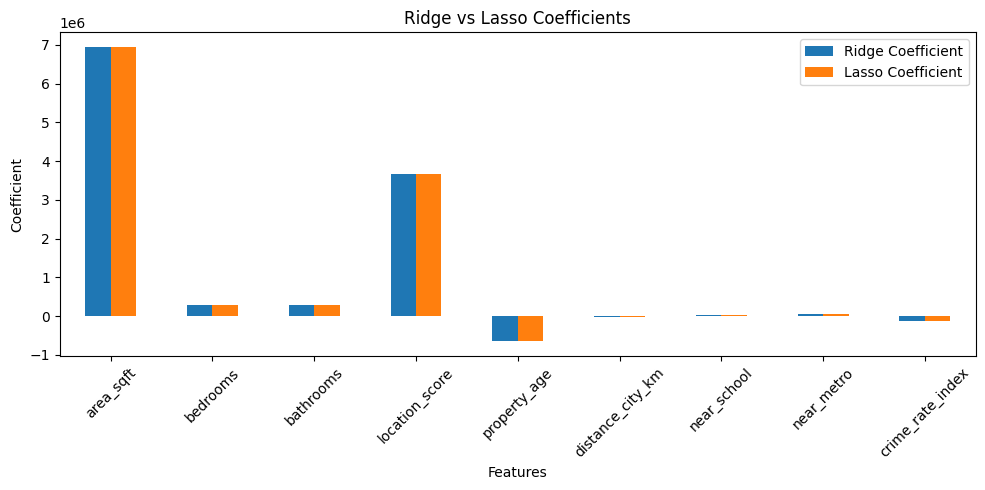

In [31]:
import matplotlib.pyplot as plt

comparison.set_index("Feature")[["Ridge Coefficient", "Lasso Coefficient"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Ridge vs Lasso Coefficients")
plt.xlabel("Features")
plt.ylabel("Coefficient")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 💡 Insight 

- **Training error:** Ridge ≈ 6.253×10¹², Lasso ≈ 6.253×10¹², practically identical.
- **Validation error:** Ridge ≈ 6.545×10¹², Lasso ≈ 6.544×10¹². Lasso is marginally better, but the difference is negligible.
- **Coefficients:** both models learn nearly the same values. `area_sqft` (~6.9×10⁶) and `location_score` (~3.7×10⁶) have the largest positive impact, while `property_age` (−6.5×10⁵) and `crime_rate_index` (−1.35×10⁵) lower the price.
- Lasso did not zero out any feature, so **all 9 features contribute something**. `near_school` and `near_metro` have the smallest impact.

## 📘 Part D: Cross-Validation Strategies

### 13. Apply and compare the following cross-validation techniques:

* K-Fold Cross-Validation

In [32]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Ridge

model = Ridge(alpha=1.0)

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

kfold_scores = cross_val_score(
    model,
    X_train_scaled,
    y_train,
    cv=kfold,
    scoring="neg_mean_squared_error"
)

kfold_mse = -kfold_scores

print("K-Fold MSE:", kfold_mse)
print("K-Fold Average MSE:", kfold_mse.mean())

K-Fold MSE: [6.31590619e+12 7.13460433e+12 6.08739446e+12 5.83257859e+12
 6.20905382e+12]
K-Fold Average MSE: 6315907476856.197


* Stratified K-Fold Cross-Validation (by binning target values)

In [33]:
from sklearn.model_selection import StratifiedKFold

# Divide target into 5 bins
y_bins = pd.qcut(y_train, q=5, labels=False)

stratified_kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

stratified_scores = []

for train_index, test_index in stratified_kfold.split(X_train_scaled, y_bins):
    
    X_train_cv = X_train_scaled[train_index]
    X_test_cv = X_train_scaled[test_index]
    
    y_train_cv = y_train.iloc[train_index]
    y_test_cv = y_train.iloc[test_index]
    
    model.fit(X_train_cv, y_train_cv)
    
    prediction = model.predict(X_test_cv)
    
    mse = mean_squared_error(y_test_cv, prediction)
    stratified_scores.append(mse)

print("Stratified K-Fold MSE:", stratified_scores)
print("Stratified K-Fold Average MSE:", sum(stratified_scores) / len(stratified_scores))

Stratified K-Fold MSE: [6546195656680.306, 6048989983626.258, 5967935004661.406, 5971654985564.865, 6963750835876.492]
Stratified K-Fold Average MSE: 6299705293281.865


* Leave-One-Out Cross-Validation

In [34]:
from sklearn.model_selection import LeaveOneOut

loo = LeaveOneOut()

loo_scores = cross_val_score(
    model,
    X_train_scaled,
    y_train,
    cv=loo,
    scoring="neg_mean_squared_error"
)

loo_mse = -loo_scores

print("LOOCV Average MSE:", loo_mse.mean())

LOOCV Average MSE: 6298363401570.2


* Time Series Split (using a time-related feature)

In [35]:
from sklearn.model_selection import TimeSeriesSplit

# Sort data according to date
df_time = df.sort_values("sale_date")

X_time = df_time[
    [
        "area_sqft",
        "bedrooms",
        "bathrooms",
        "location_score",
        "property_age",
        "distance_city_km",
        "near_school",
        "near_metro",
        "crime_rate_index"
    ]
]

y_time = df_time["house_price_inr"]

# Scale the data
X_time_scaled = scaler.fit_transform(X_time)

time_split = TimeSeriesSplit(n_splits=5)

time_scores = cross_val_score(
    model,
    X_time_scaled,
    y_time,
    cv=time_split,
    scoring="neg_mean_squared_error"
)

time_mse = -time_scores

print("Time Series MSE:", time_mse)
print("Time Series Average MSE:", time_mse.mean())

Time Series MSE: [6.93104908e+12 6.08525180e+12 6.01807233e+12 6.05795363e+12
 6.80041024e+12]
Time Series Average MSE: 6378547416733.665


### 💡 Insight  

- The average MSE across all four strategies lies between 6.30 and 6.38×10¹², so the **estimated performance is consistent**.
- Individual K-Fold scores ranged from 5.83×10¹² to 7.13×10¹², showing **fold-to-fold variation**. Relying on a single split would be risky.
- Time Series Split trains only on past data and tests on future data, so it gives the most realistic (and slightly pessimistic) estimate.

### 14. Analyze how performance metrics vary across different CV strategies.

In [36]:
cv_results = pd.DataFrame({
    "CV Strategy": [
        "K-Fold",
        "Stratified K-Fold",
        "Leave-One-Out",
        "Time Series Split"
    ],
    "Average MSE": [
        kfold_mse.mean(),
        sum(stratified_scores) / len(stratified_scores),
        loo_mse.mean(),
        time_mse.mean()
    ]
})

print(cv_results)

         CV Strategy   Average MSE
0             K-Fold  6.315907e+12
1  Stratified K-Fold  6.299705e+12
2      Leave-One-Out  6.298363e+12
3  Time Series Split  6.378547e+12


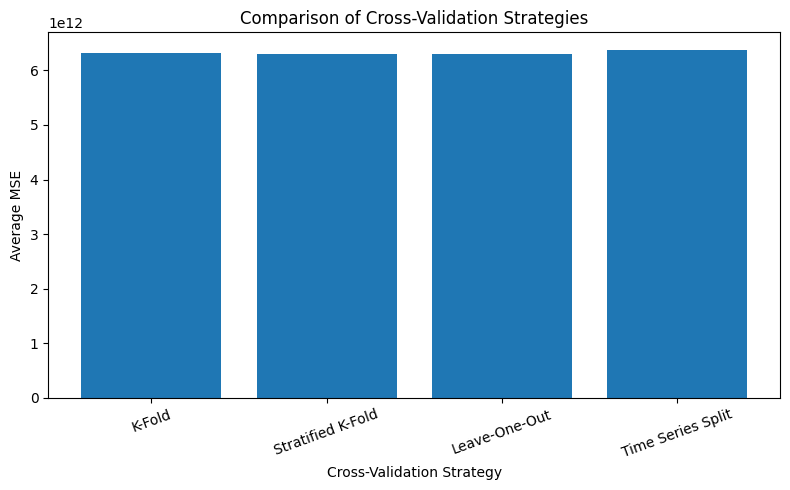

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    cv_results["CV Strategy"],
    cv_results["Average MSE"]
)

plt.xlabel("Cross-Validation Strategy")
plt.ylabel("Average MSE")
plt.title("Comparison of Cross-Validation Strategies")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 💡 Insight

- **Leave-One-Out (6.298×10¹²)** and **Stratified K-Fold (6.300×10¹²)** give the lowest MSE, while **Time Series Split (6.379×10¹²)** gives the highest.
- The gap between the lowest and highest is only ~1.3%, so there is **no major trend or drift over time** in the data.
- LOOCV gives almost the same estimate as K-Fold at a much higher computational cost, so **5-fold K-Fold is sufficient** in practice.

## 🌳 Part E: Tree-Based Regression Models

###  15. Implement Decision Tree Regression.

In [38]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

tree = DecisionTreeRegressor(random_state=42)

tree.fit(X_train, y_train)

tree_train_pred = tree.predict(X_train)
tree_test_pred = tree.predict(X_test)

tree_train_mse = mean_squared_error(y_train, tree_train_pred)
tree_test_mse = mean_squared_error(y_test, tree_test_pred)

tree_train_r2 = r2_score(y_train, tree_train_pred)
tree_test_r2 = r2_score(y_test, tree_test_pred)

print("Decision Tree Training MSE:", tree_train_mse)
print("Decision Tree Validation MSE:", tree_test_mse)

print("Decision Tree Training R2:", tree_train_r2)
print("Decision Tree Validation R2:", tree_test_r2)

Decision Tree Training MSE: 0.0
Decision Tree Validation MSE: 11418620582615.756
Decision Tree Training R2: 1.0
Decision Tree Validation R2: 0.8582157251362128


### 💡 Insight 

- The unrestricted tree has **Training MSE = 0 and Training R² = 1.0**, but **Validation R² is only 0.858**. This is clear **overfitting**: the tree memorized the training data.
- Its validation MSE (≈ 1.14×10¹³) is about 75% higher than Ridge's.

### 16. Control tree complexity using hyperparameters (max depth, min samples).

In [40]:
tree = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

tree.fit(X_train, y_train)

tree_train_pred = tree.predict(X_train)
tree_test_pred = tree.predict(X_test)

tree_train_mse = mean_squared_error(y_train, tree_train_pred)
tree_test_mse = mean_squared_error(y_test, tree_test_pred)

print("Training MSE:", tree_train_mse)
print("Validation MSE:", tree_test_mse)

Training MSE: 7503005055146.253
Validation MSE: 9385836459040.166


### 💡 Insight

- With `max_depth=5`, `min_samples_split=10` and `min_samples_leaf=5`, validation MSE **drops from 1.14×10¹³ to 9.39×10¹²** (~18% better).
- The train-validation gap is now much smaller (7.50×10¹² vs 9.39×10¹²), so overfitting is greatly reduced.
- The tree still trails Ridge (6.55×10¹²) because it makes step-wise predictions, while price changes roughly smoothly and linearly with the features.

### 17. Implement Random Forest Regression.


In [41]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

forest.fit(X_train, y_train)

forest_train_pred = forest.predict(X_train)
forest_test_pred = forest.predict(X_test)

forest_train_mse = mean_squared_error(y_train, forest_train_pred)
forest_test_mse = mean_squared_error(y_test, forest_test_pred)

forest_train_r2 = r2_score(y_train, forest_train_pred)
forest_test_r2 = r2_score(y_test, forest_test_pred)

print("Random Forest Training MSE:", forest_train_mse)
print("Random Forest Validation MSE:", forest_test_mse)

print("Random Forest Training R2:", forest_train_r2)
print("Random Forest Validation R2:", forest_test_r2)

Random Forest Training MSE: 5505101254770.176
Random Forest Validation MSE: 6904658266616.438
Random Forest Training R2: 0.92621072099327
Random Forest Validation R2: 0.9142653039015152


### 💡 Insight 

- Random Forest reaches a **Validation R² of 0.914** and **Validation MSE ≈ 6.90×10¹²**, with only a ~0.012 gap from its training R² of 0.926.
- Compared with the single tree (9.39×10¹²), validation MSE is **~26% lower**, because averaging many trees reduces variance.

### 18. Compare single-tree vs ensemble performance.

In [42]:
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest"
    ],
    "Training MSE": [
        tree_train_mse,
        forest_train_mse
    ],
    "Validation MSE": [
        tree_test_mse,
        forest_test_mse
    ],
    "Training R2": [
        tree_train_r2,
        forest_train_r2
    ],
    "Validation R2": [
        tree_test_r2,
        forest_test_r2
    ]
})

print(comparison)

           Model  Training MSE  Validation MSE  Training R2  Validation R2
0  Decision Tree  7.503005e+12    9.385836e+12     1.000000       0.858216
1  Random Forest  5.505101e+12    6.904658e+12     0.926211       0.914265


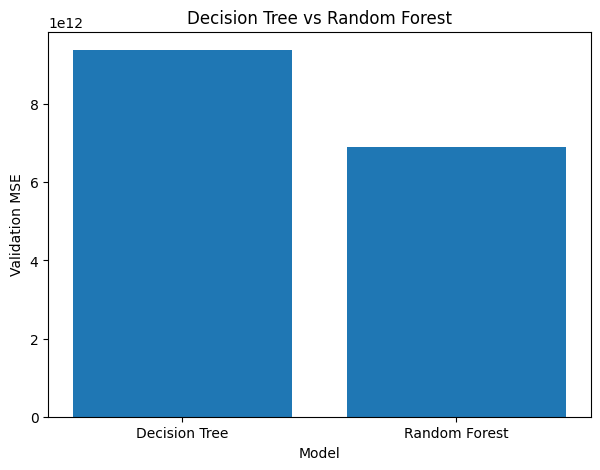

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    comparison["Model"],
    comparison["Validation MSE"]
)

plt.xlabel("Model")
plt.ylabel("Validation MSE")
plt.title("Decision Tree vs Random Forest")
plt.show()

### 💡 Insight

- Random Forest is **better on every metric**: Validation MSE 6.90×10¹² vs 9.39×10¹², and Validation R² 0.914 vs 0.883 (tuned tree).
- The ensemble benefit: lower variance, less overfitting and more stable predictions.
- ⚠️ Note: in this table the Decision Tree's *Training R²* shows `1.0`, which is the value from the **unpruned tree** in Q15, while the MSE columns come from the tuned tree (Q16). The tuned tree's actual Training R² is ≈ 0.899 (shown in Q24).

## ◢ Part F: Support Vector Regression

### 19. Implement Support Vector Regression (SVR) with

* Linear kernel


In [44]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

svr_linear = SVR(kernel="linear")

svr_linear.fit(X_train_scaled, y_train)

svr_linear_train_pred = svr_linear.predict(X_train_scaled)
svr_linear_test_pred = svr_linear.predict(X_test_scaled)

print("SVR Linear Training MSE:",
      mean_squared_error(y_train, svr_linear_train_pred))

print("SVR Linear Validation MSE:",
      mean_squared_error(y_test, svr_linear_test_pred))

print("SVR Linear Validation R2:",
      r2_score(y_test, svr_linear_test_pred))

SVR Linear Training MSE: 75040461008943.1
SVR Linear Validation MSE: 80689290813854.28
SVR Linear Validation R2: -0.0019137166824763074


* Polynomial or RBF kernel

In [45]:
svr_rbf = SVR(kernel="rbf")

svr_rbf.fit(X_train_scaled, y_train)

svr_rbf_train_pred = svr_rbf.predict(X_train_scaled)
svr_rbf_test_pred = svr_rbf.predict(X_test_scaled)

print("SVR RBF Training MSE:",
      mean_squared_error(y_train, svr_rbf_train_pred))

print("SVR RBF Validation MSE:",
      mean_squared_error(y_test, svr_rbf_test_pred))

print("SVR RBF Validation R2:",
      r2_score(y_test, svr_rbf_test_pred))

SVR RBF Training MSE: 75119288031689.58
SVR RBF Validation MSE: 80772044778137.69
SVR RBF Validation R2: -0.002941267316384888


### 💡 Insight

- Both kernels give **R² ≈ 0** and MSE ≈ 8.07×10¹³, which equals the variance of the target (~7.6×10¹³). The model is essentially **predicting the mean price every time**.
- The kernel is not the problem. The target (`y`) is on the ₹10⁷ scale while the default `C=1` and `ε=0.1` are far too small, so SVR cannot fit the data.

### 20. Tune hyperparameters (C, γ, ε).

In [46]:
from sklearn.model_selection import GridSearchCV

parameters = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.01, 0.1],
    "epsilon": [0.1, 0.5, 1]
}

svr = SVR(kernel="rbf")

svr_grid = GridSearchCV(
    svr,
    parameters,
    cv=5,
    scoring="neg_mean_squared_error"
)

svr_grid.fit(X_train_scaled, y_train)

print("Best Parameters:", svr_grid.best_params_)

Best Parameters: {'C': 10, 'epsilon': 0.1, 'gamma': 0.1}


In [47]:
best_svr = svr_grid.best_estimator_

svr_train_pred = best_svr.predict(X_train_scaled)
svr_test_pred = best_svr.predict(X_test_scaled)

print("Tuned SVR Training MSE:",
      mean_squared_error(y_train, svr_train_pred))

print("Tuned SVR Validation MSE:",
      mean_squared_error(y_test, svr_test_pred))

print("Tuned SVR Validation R2:",
      r2_score(y_test, svr_test_pred))

Tuned SVR Training MSE: 75098344832723.34
Tuned SVR Validation MSE: 80750348039740.02
Tuned SVR Validation R2: -0.002671860315918595


### 💡 Insight 

- Best parameters are **C=10, γ=0.1, ε=0.1**, yet R² is still ≈ −0.003, so tuning did not help.
- `C=10` is the upper edge of the grid and is still tiny relative to the target scale. The fix is to **scale the target** (e.g. `TransformedTargetRegressor`) or use a **much larger C** (10⁶+).

### 21. Compare SVR performance with linear and tree-based models.

In [48]:
# Linear Model - Ridge
ridge_pred = best_ridge.predict(X_test_scaled)

# Decision Tree
tree_pred = tree.predict(X_test)

# Random Forest
forest_pred = forest.predict(X_test)

# SVR
svr_pred = best_svr.predict(X_test_scaled)

comparison_21 = pd.DataFrame({
    "Model": [
        "Ridge",
        "Decision Tree",
        "Random Forest",
        "SVR"
    ],
    "MSE": [
        mean_squared_error(y_test, ridge_pred),
        mean_squared_error(y_test, tree_pred),
        mean_squared_error(y_test, forest_pred),
        mean_squared_error(y_test, svr_pred)
    ],
    "R2 Score": [
        r2_score(y_test, ridge_pred),
        r2_score(y_test, tree_pred),
        r2_score(y_test, forest_pred),
        r2_score(y_test, svr_pred)
    ]
})

print(comparison_21)

           Model           MSE  R2 Score
0          Ridge  6.545419e+12  0.918726
1  Decision Tree  9.385836e+12  0.883457
2  Random Forest  6.904658e+12  0.914265
3            SVR  8.075035e+13 -0.002672


### 💡 Insight

- R² ranking: **Ridge 0.919 > Random Forest 0.914 > Decision Tree 0.883 >> SVR ≈ 0**.
- Simple **Ridge performs best**, which suggests the relationship between price and features is mostly linear and complex non-linear models add little here.
- SVR is the worst (MSE ≈ 8.08×10¹³, roughly 10× the others) for the reasons explained in Q19–Q20.

## 📊 Part G: Model Comparison & Evaluation

### 22. Evaluate all models using appropriate regression metrics:

* MSE, MAE, RMSE
* R² Score

In [49]:
import numpy as np

models = {
    "Ridge": (y_test, ridge_pred),
    "Lasso": (y_test, best_lasso.predict(X_test_scaled)),
    "Decision Tree": (y_test, tree_pred),
    "Random Forest": (y_test, forest_pred),
    "SVR": (y_test, svr_pred)
}

results = []

for name, (actual, prediction) in models.items():

    mse = mean_squared_error(actual, prediction)
    mae = mean_absolute_error(actual, prediction)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, prediction)

    results.append([
        name,
        mse,
        mae,
        rmse,
        r2
    ])

results_df = pd.DataFrame(
    results,
    columns=["Model", "MSE", "MAE", "RMSE", "R2 Score"]
)

print(results_df)

           Model           MSE           MAE          RMSE  R2 Score
0          Ridge  6.545419e+12  1.959199e+06  2.558402e+06  0.918726
1          Lasso  6.544107e+12  1.959385e+06  2.558145e+06  0.918742
2  Decision Tree  9.385836e+12  2.325304e+06  3.063631e+06  0.883457
3  Random Forest  6.904658e+12  1.936690e+06  2.627672e+06  0.914265
4            SVR  8.075035e+13  6.992913e+06  8.986120e+06 -0.002672


### 💡 Insight 

- **Best RMSE:** Lasso (≈ ₹25.58 lakh), with Ridge almost the same. **Best MAE:** Random Forest (≈ ₹19.37 lakh).
- The average absolute error is ≈ ₹19.6 lakh, about **9–10% of the price**, which is reasonable accuracy.
- Random Forest has the lowest MAE but a slightly higher RMSE than the linear models, meaning **typical predictions are good but it makes some larger errors**.
- SVR's RMSE (≈ ₹89.9 lakh) and MAE (≈ ₹69.9 lakh) are far above the rest.

### 23. Compare:

* Regularized Linear Models
* Tree-Based Models
* Support Vector Regression



In [52]:
print(results_df.sort_values("RMSE"))

           Model           MSE           MAE          RMSE  R2 Score
1          Lasso  6.544107e+12  1.959385e+06  2.558145e+06  0.918742
0          Ridge  6.545419e+12  1.959199e+06  2.558402e+06  0.918726
3  Random Forest  6.904658e+12  1.936690e+06  2.627672e+06  0.914265
2  Decision Tree  9.385836e+12  2.325304e+06  3.063631e+06  0.883457
4            SVR  8.075035e+13  6.992913e+06  8.986120e+06 -0.002672


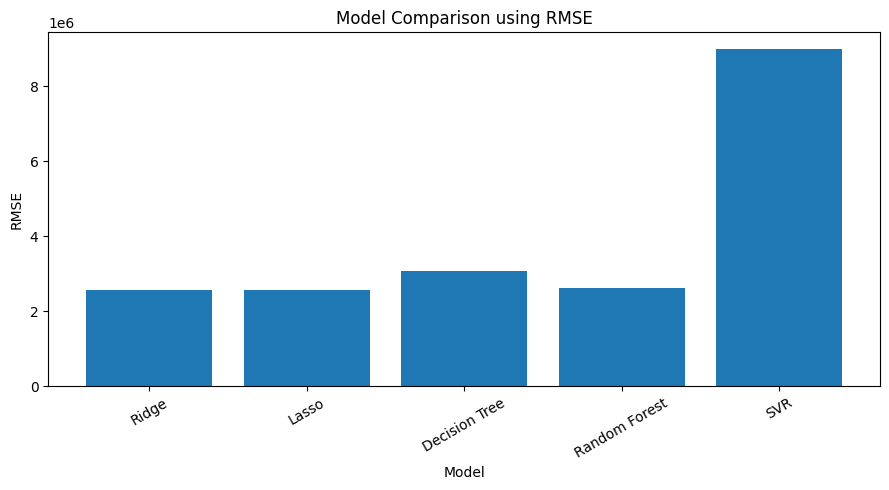

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    results_df["Model"],
    results_df["RMSE"]
)

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Model Comparison using RMSE")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 💡 Insight 

- **Regularized Linear (Ridge/Lasso):** best and simplest, with R² ≈ 0.9187 and interpretable coefficients.
- **Tree-based:** Random Forest (R² 0.914) is very close to the linear models, while the single Decision Tree (0.883) is weaker.
- **SVR:** fails in the current setup (R² ≈ 0) because of the unscaled target.
- Final ranking by RMSE: **Lasso ≈ Ridge < Random Forest < Decision Tree << SVR**.

### 24. Identify signs of overfitting or underfitting in each model.

In [54]:
overfitting_results = []

# Ridge
ridge_train_r2 = r2_score(y_train, best_ridge.predict(X_train_scaled))
ridge_test_r2 = r2_score(y_test, ridge_pred)

# Lasso
lasso_train_r2 = r2_score(y_train, best_lasso.predict(X_train_scaled))
lasso_test_r2 = r2_score(y_test, best_lasso.predict(X_test_scaled))

# Decision Tree
tree_train_r2 = r2_score(y_train, tree_train_pred)
tree_test_r2 = r2_score(y_test, tree_test_pred)

# Random Forest
forest_train_r2 = r2_score(y_train, forest_train_pred)
forest_test_r2 = r2_score(y_test, forest_test_pred)

# SVR
svr_train_r2 = r2_score(y_train, svr_train_pred)
svr_test_r2 = r2_score(y_test, svr_test_pred)

model_r2 = {
    "Ridge": (ridge_train_r2, ridge_test_r2),
    "Lasso": (lasso_train_r2, lasso_test_r2),
    "Decision Tree": (tree_train_r2, tree_test_r2),
    "Random Forest": (forest_train_r2, forest_test_r2),
    "SVR": (svr_train_r2, svr_test_r2)
}

for model, (train_r2, test_r2) in model_r2.items():

    difference = train_r2 - test_r2

    if difference > 0.10:
        result = "Overfitting"
    elif train_r2 < 0.60 and test_r2 < 0.60:
        result = "Underfitting"
    else:
        result = "Good Fit"

    overfitting_results.append([
        model,
        train_r2,
        test_r2,
        result
    ])

fit_results = pd.DataFrame(
    overfitting_results,
    columns=["Model", "Training R2", "Validation R2", "Fit"]
)

print(fit_results)

           Model  Training R2  Validation R2           Fit
0          Ridge     0.916185       0.918726      Good Fit
1          Lasso     0.916186       0.918742      Good Fit
2  Decision Tree     0.899431       0.883457      Good Fit
3  Random Forest     0.926211       0.914265      Good Fit
4            SVR    -0.006603      -0.002672  Underfitting


### 💡 Insight 

- **Ridge & Lasso:** Train R² ≈ 0.916, Validation R² ≈ 0.919 → **Good Fit**, no overfitting.
- **Random Forest:** 0.926 vs 0.914 (gap ≈ 0.012) → **Good Fit**. **Decision Tree (tuned):** 0.899 vs 0.883 (gap ≈ 0.016) → **Good Fit**. Without pruning (Q15) it clearly overfit.
- **SVR:** both Train and Validation R² ≈ 0 → **Underfitting**, mainly caused by the target scale rather than the model type.

## 🏁 Final Conclusion

| Model | Validation R² | RMSE (₹) | Fit |
|---|---|---|---|
| Lasso | 0.9187 | ≈ 25.58 lakh | Good Fit |
| Ridge | 0.9187 | ≈ 25.58 lakh | Good Fit |
| Random Forest | 0.9143 | ≈ 26.28 lakh | Good Fit |
| Decision Tree (tuned) | 0.8835 | ≈ 30.64 lakh | Good Fit |
| SVR (RBF, tuned) | ≈ 0.00 | ≈ 89.86 lakh | Underfitting |

**Key takeaways**

- **Best model:** Regularized linear models (Lasso ≈ Ridge) have the lowest RMSE, show no overfitting, and are simple and interpretable. Random Forest is a very close second.
- **Most important features:** `area_sqft` and `location_score` raise price the most, while `property_age`, `crime_rate_index` and `distance_city_km` lower it.
- **Cross-validation:** All strategies (K-Fold, Stratified, LOOCV, Time Series) gave an MSE around 6.3×10¹², so the results are **stable and reliable**.
- **Regularization:** With only 9 features and a strong signal, Ridge and Lasso performed almost identically, and Lasso did not zero out any feature.
- **Trees:** An unpruned tree overfits; pruning and ensembling (Random Forest) improve generalization.
- **SVR:** It failed because the target was not scaled. This is a preprocessing limitation, not a problem with the kernel or tuning.

**Suggested improvements**

1. Scale the target (or use a much larger `C`) for SVR.
2. Use a wider α grid for Lasso.
3. Tune Random Forest / Gradient Boosting with `GridSearchCV`.
4. Engineer year/month features from `sale_date` and run residual analysis.

**Overall:** The relationship between price and features in this dataset is mostly linear, so **Lasso/Ridge are the most balanced and reliable choice**, with Random Forest as a strong alternative.